# Lab 5.1 — Adversarial Examples and Model Robustness  *(SOLUTION / instructor copy)*

**Chapter 5 — AI Security, Risks, and Responsible AI** · 40 minutes *(flex)*

**Objectives**
1. Craft inputs that flip a model's prediction.
2. Measure how much perturbation it actually takes.
3. Name the defences that would have helped.

In [1]:
# Instructor copies live in solutions/, one level below labs/ — find labs/
# (where lab_common.py and data/ are) and run from there.
import os, sys
from pathlib import Path

for _cand in (Path.cwd(), Path.cwd().parent):
    if (_cand / "lab_common.py").is_file():
        os.chdir(_cand)
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

## Step 1 — Train the small classifier

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

epa = pd.read_csv("data/epa_aqi_by_county.csv")
epa["poor_air"] = ((epa["Unhealthy Days"] + epa["Very Unhealthy Days"]
                    + epa["Hazardous Days"]) > 0).astype(int)

FEATURES = ["Good Days", "Moderate Days",
            "Unhealthy for Sensitive Groups Days", "Days with AQI"]
X = epa[FEATURES].values
y = epa["poor_air"].values
print(f"{len(epa)} counties | positive (poor air): {y.sum()} ({y.mean():.0%})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)

997 counties | positive (poor air): 159 (16%)


## Step 2 — Baseline accuracy

**Expected:** ~86.8%. The model leans hardest on
`Unhealthy for Sensitive Groups Days` (coefficient ≈ +1.8) — which tells the
attacker exactly where to push. Model transparency cuts both ways.

In [3]:
baseline = clf.score(scaler.transform(X_test), y_test)
print(f"baseline accuracy: {baseline:.1%}")
print("coefficients:", dict(zip(FEATURES, clf.coef_[0].round(2))))

baseline accuracy: 86.8%
coefficients: {'Good Days': np.float64(-0.73), 'Moderate Days': np.float64(-0.5), 'Unhealthy for Sensitive Groups Days': np.float64(1.8), 'Days with AQI': np.float64(1.18)}


## Step 3 — The smallest change that flips one prediction

**Expected:** for the reference sample (a clean county), just **+19 USG
days** flips it to "poor air" — the model never asks whether 19 extra days
is plausible given the county's other counts. Smaller than students expect;
that is the lesson.

In [4]:
def predict_raw(row):
    return clf.predict(scaler.transform([row]))[0]

correct = np.where(clf.predict(scaler.transform(X_test)) == y_test)[0]
sample = X_test[correct[5]].copy()
print("sample county:", dict(zip(FEATURES, sample)), "| true label:", y_test[correct[5]])

smallest_flip = None
for jj, f in enumerate(FEATURES):
    for eps in range(1, 400):
        x = sample.copy()
        x[jj] += eps
        if predict_raw(x) != y_test[correct[5]]:
            smallest_flip = (f, eps)
            break
    if smallest_flip:
        break
print(f"smallest flip found: {smallest_flip[0]} +{smallest_flip[1]} days")

sample county: {'Good Days': np.int64(106), 'Moderate Days': np.int64(16), 'Unhealthy for Sensitive Groups Days': np.int64(0), 'Days with AQI': np.int64(122)} | true label: 0
smallest flip found: Unhealthy for Sensitive Groups Days +19 days


## Step 4 — Flip rate vs. perturbation size

**Expected curve:** ~1% at ε=1, ~26% at ε=10, ~84% at ε=20, plateau ~85%.
The remaining ~15% are counties whose other features dominate — no single-
feature attack moves them. State it plainly: a 20-day edit flips five out
of six predictions while baseline accuracy stays a marketing number.

eps=  1 days -> flip rate 1%
eps=  2 days -> flip rate 2%
eps=  5 days -> flip rate 5%
eps= 10 days -> flip rate 26%
eps= 20 days -> flip rate 84%
eps= 40 days -> flip rate 85%


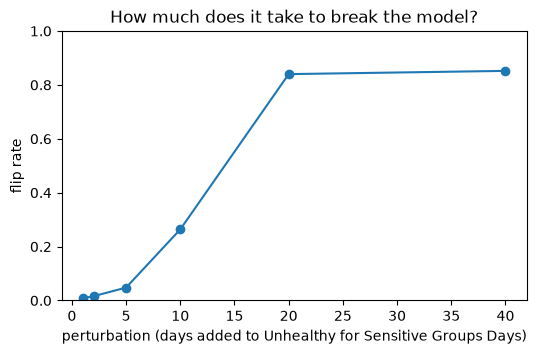

In [5]:
SENSITIVE = "Unhealthy for Sensitive Groups Days"
j = FEATURES.index(SENSITIVE)

def flip_rate(model, sc, eps):
    Xp = X_test.copy().astype(float)
    Xp[:, j] = np.clip(Xp[:, j] + np.where(y_test == 1, -eps, eps), 0, None)
    flipped = (model.predict(sc.transform(Xp)) != y_test)
    was_correct = model.predict(sc.transform(X_test)) == y_test
    return float((flipped & was_correct).mean())

EPSILONS = [1, 2, 5, 10, 20, 40]
rates = [flip_rate(clf, scaler, e) for e in EPSILONS]
for e, r in zip(EPSILONS, rates):
    print(f"eps={e:>3} days -> flip rate {r:.0%}")

plt.figure(figsize=(6, 3.5))
plt.plot(EPSILONS, rates, marker="o")
plt.xlabel(f"perturbation (days added to {SENSITIVE})")
plt.ylabel("flip rate")
plt.title("How much does it take to break the model?")
plt.ylim(0, 1)
plt.show()

## Step 5 — Defence: adversarial retraining

**Expected:** flip rate collapses to ~0% at every ε tested, with accuracy
unchanged (~86.8%). Then the honest caveat: this defence covers *this*
attack. An attacker who knows we retrained on USG-day perturbations will
perturb `Good Days` downward or `Moderate Days` instead — re-measure and
some flips return. Defence is a moving target, not a checkbox.

(A second defence worth mentioning in debrief: a **consistency check** —
day counts that sum above `Days with AQI` are physically impossible, so the
application layer should reject them before the model ever sees them.)

In [6]:
rng = np.random.default_rng(0)
aug_X, aug_y = [X_train], [y_train]
for eps in (5, 10, 20, 40):
    Xa = X_train.copy().astype(float)
    Xa[:, j] = np.clip(Xa[:, j] + np.where(y_train == 1, -eps, eps)
                       * rng.uniform(0.5, 1.0, len(y_train)), 0, None)
    aug_X.append(Xa)
    aug_y.append(y_train)
X_aug, y_aug = np.vstack(aug_X), np.concatenate(aug_y)
scaler2 = StandardScaler().fit(X_aug)
clf2 = LogisticRegression(max_iter=1000).fit(scaler2.transform(X_aug), y_aug)

print(f"retrained accuracy: {clf2.score(scaler2.transform(X_test), y_test):.1%}")
defended_rates = [flip_rate(clf2, scaler2, e) for e in EPSILONS]
print("eps   before -> after defence")
for e, b, a in zip(EPSILONS, rates, defended_rates):
    print(f"{e:>3}   {b:5.0%}  ->  {a:.0%}")

retrained accuracy: 86.8%
eps   before -> after defence
  1      1%  ->  0%
  2      2%  ->  0%
  5      5%  ->  0%
 10     26%  ->  0%
 20     84%  ->  0%
 40     85%  ->  0%


### Three sentences to the system owner (worked)

"Before any mitigation, editing a single input field by about twenty days
flipped five out of six of the model's predictions while its headline
accuracy stayed 87% — so accuracy alone is not evidence of robustness. We
retrained the model on perturbed examples and the same attack now flips
effectively nothing, at no cost to accuracy. The remaining exposure is an
attacker who adapts to the defence, so input validation at the application
layer and periodic re-testing need to be part of operating this model, not
one-time fixes."

## Reflection (expected answers)
1. +19 days on one feature for the reference county — single-feature edits
   in the tens, not thousands.
2. Not fully: retraining covers the attack it was shown. An adaptive
   attacker perturbs a different feature (try it: `Good Days` downward) —
   which is why red-teaming is iterative.
3. Evasion — crafting adversarial data to defeat a model at inference time
   (ATLAS tactic AML.TA0015 *Evade ML Model*, technique family *Craft
   Adversarial Data*).